In [1]:
# %% [markdown]
# # Training cWGAN-GP for Minority Class Oversampling (Improved Version)
# 
# This notebook trains an enhanced Conditional Wasserstein GAN with Gradient Penalty (cWGAN-GP) to generate synthetic minority class samples for the German Credit dataset.
# 
# **Improvements over baseline:**
# - MinMaxScaler for numerical features (output range [0,1], no negatives)
# - Sigmoid activation in generator numerical head
# - Latent dimension increased to 256
# - Gumbel-Softmax for categorical generation
# - Training for 3000 epochs
# - Post-generation clipping to original feature ranges

# %% [markdown]
# ## 1. Setup and Imports


In [1]:
# %%
%load_ext autoreload


In [2]:

%autoreload 2


In [3]:

import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import joblib

# Add scripts folder to path
sys.path.append(os.path.abspath("../scripts"))

from gan_util import build_feature_info, split_num_cat, combine_num_cat
from cwgan_gp import CWGANGP
from evaluation import *
from data_balancing import (
    prepare_minority_data_for_gan, 
    train_cwgan_on_minority,
    generate_synthetic_samples,            
    prepare_full_data_for_gan, 
    train_cwgan_full
)

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)


In [5]:
# Check TensorFlow GPU availability (optional)
print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.12.0
GPU Available: []


In [6]:

# %% [markdown]
# ## 2. Load Processed Data and Feature Info

# %%
# Load one-hot encoded data (from feature engineering)
df_processed = pd.read_csv("../data/processed/german_processed_onehot.csv")
print("Shape:", df_processed.shape)
df_processed.head()


Shape: (1000, 77)


,Duration,CreditAmount,Age,Class,Credit_per_Duration,CheckingAccountStatus_A11,CheckingAccountStatus_A12,CheckingAccountStatus_A13,CheckingAccountStatus_A14,CreditHistory_A30,...,Dependents_1,Dependents_2,Telephone_A191,Telephone_A192,ForeignWorker_A201,ForeignWorker_A202,AgeGroup_Young,AgeGroup_Adult,AgeGroup_Mature,AgeGroup_Senior
0,6,1169,67,0,194.833333,True,False,False,False,False,...,True,False,False,True,True,False,False,False,False,True
1,48,5951,22,1,123.979167,False,True,False,False,False,...,True,False,True,False,True,False,True,False,False,False
2,12,2096,49,0,174.666667,False,False,False,True,False,...,False,True,True,False,True,False,False,False,True,False
3,42,7882,45,0,187.666667,True,False,False,False,False,...,False,True,True,False,True,False,False,False,True,False
4,24,4870,53,1,202.916667,True,False,False,False,False,...,False,True,True,False,True,False,False,False,True,False


In [7]:

# %%
# Load feature info and column order
feature_info = joblib.load("../models/feature_info.pkl")
column_order = joblib.load("../models/column_order.pkl")
cat_cols_original = joblib.load("../models/cat_cols.pkl")

print("Numerical features:", feature_info['numerical'])
print("Categorical groups:")
for k, v in feature_info['categorical'].items():
    print(f"  {k}: {len(v)} categories")


Numerical features: ['Duration', 'CreditAmount', 'Age', 'Credit_per_Duration']
Categorical groups:
  CheckingAccountStatus: 4 categories
  CreditHistory: 5 categories
  Purpose: 10 categories
  SavingsAccount: 5 categories
  EmploymentSince: 5 categories
  InstallmentRate: 4 categories
  PersonalStatusSex: 4 categories
  OtherDebtors: 3 categories
  ResidenceSince: 4 categories
  Property: 4 categories
  OtherInstallmentPlans: 3 categories
  Housing: 3 categories
  ExistingCredits: 4 categories
  Job: 4 categories
  Dependents: 2 categories
  Telephone: 2 categories
  ForeignWorker: 2 categories
  AgeGroup: 4 categories


In [8]:

# %% [markdown]
# ## 3. Check Class Imbalance

# %%
target_col = 'Class'
minority_label = 1  # bad credit

counts = df_processed[target_col].value_counts()
print(counts)
print(f"Imbalance ratio: {counts[0] / counts[1]:.2f}:1")


Class
0    700
1    300
Name: count, dtype: int64
Imbalance ratio: 2.33:1


In [9]:
# %% [markdown]
# ## 4. Prepare Full Data for GAN (with MinMaxScaler and Conditioning)

# %%
# 1. Prepare the dataset for training (this also fits the scaler internally)
dataset, scaler, n_num, n_cat_dims, num_scaled, cat_list = prepare_full_data_for_gan(
    df_processed,              # ← full 1000 samples
    feature_info,
    target_col,
    minority_label,
    batch_size=64
)

# 3. Print the desired output
print("Total samples:", len(df_processed))
if n_num > 0:
    print("Numerical features shape (scaled 0-1):", num_scaled.shape)
    print("Numerical value ranges:")
    for i, col in enumerate(feature_info['numerical']):
        print(f"  {col}: min={num_scaled[:, i].min():.4f}, max={num_scaled[:, i].max():.4f}")
for i, arr in enumerate(cat_list):
    print(f"Categorical group {i} shape: {arr.shape}")

print(f"\nDataset ready. Numerical features: {n_num}, Categorical groups: {len(n_cat_dims)}")

Total samples: 1000
Numerical features shape (scaled 0-1): (1000, 4)
Numerical value ranges:
  Duration: min=0.0000, max=1.0000
  CreditAmount: min=0.0000, max=1.0000
  Age: min=0.0000, max=1.0000
  Credit_per_Duration: min=0.0000, max=1.0000
Categorical group 0 shape: (1000, 4)
Categorical group 1 shape: (1000, 5)
Categorical group 2 shape: (1000, 10)
Categorical group 3 shape: (1000, 5)
Categorical group 4 shape: (1000, 5)
Categorical group 5 shape: (1000, 4)
Categorical group 6 shape: (1000, 4)
Categorical group 7 shape: (1000, 3)
Categorical group 8 shape: (1000, 4)
Categorical group 9 shape: (1000, 4)
Categorical group 10 shape: (1000, 3)
Categorical group 11 shape: (1000, 3)
Categorical group 12 shape: (1000, 4)
Categorical group 13 shape: (1000, 4)
Categorical group 14 shape: (1000, 2)
Categorical group 15 shape: (1000, 2)
Categorical group 16 shape: (1000, 2)
Categorical group 17 shape: (1000, 4)

Dataset ready. Numerical features: 4, Categorical groups: 18


In [12]:
# %% [markdown]
# ## 5. Train cWGAN-GP on Full 1000 Samples

# %%
gan, scaler = train_cwgan_full(
    df_train=df_processed,      # ← full dataset
    feature_info=feature_info,
    target_col=target_col,
    minority_label=minority_label,
    latent_dim=256,
    epochs=3000,
    batch_size=64,
    n_critic=5,
    gp_weight=10.0,
    aux_weight=1.0,
    learning_rate=1e-4,
    gumbel_temperature=0.5,
    verbose=True,
    save_path='../models/cwgan_full/'
)

Epoch 10/3000 | C Loss: -3.2430 | G Loss: -4.7776 | W Dist: 3.2098 | GP: 0.0339
Epoch 20/3000 | C Loss: -2.8694 | G Loss: -5.5110 | W Dist: 2.8530 | GP: 0.0240
Epoch 30/3000 | C Loss: -2.4790 | G Loss: -5.9474 | W Dist: 2.5064 | GP: 0.0206
Epoch 40/3000 | C Loss: -2.4407 | G Loss: -6.0909 | W Dist: 2.4575 | GP: 0.0218
Epoch 50/3000 | C Loss: -2.1748 | G Loss: -6.6189 | W Dist: 2.1405 | GP: 0.0179
Epoch 60/3000 | C Loss: -2.2770 | G Loss: -6.7932 | W Dist: 2.2449 | GP: 0.0190

Early stopping at epoch 62 (Wasserstein distance did not improve for 50 epochs)

Training completed! Best Wasserstein Distance: 3.3195
Model saved to ../models/cwgan_full/


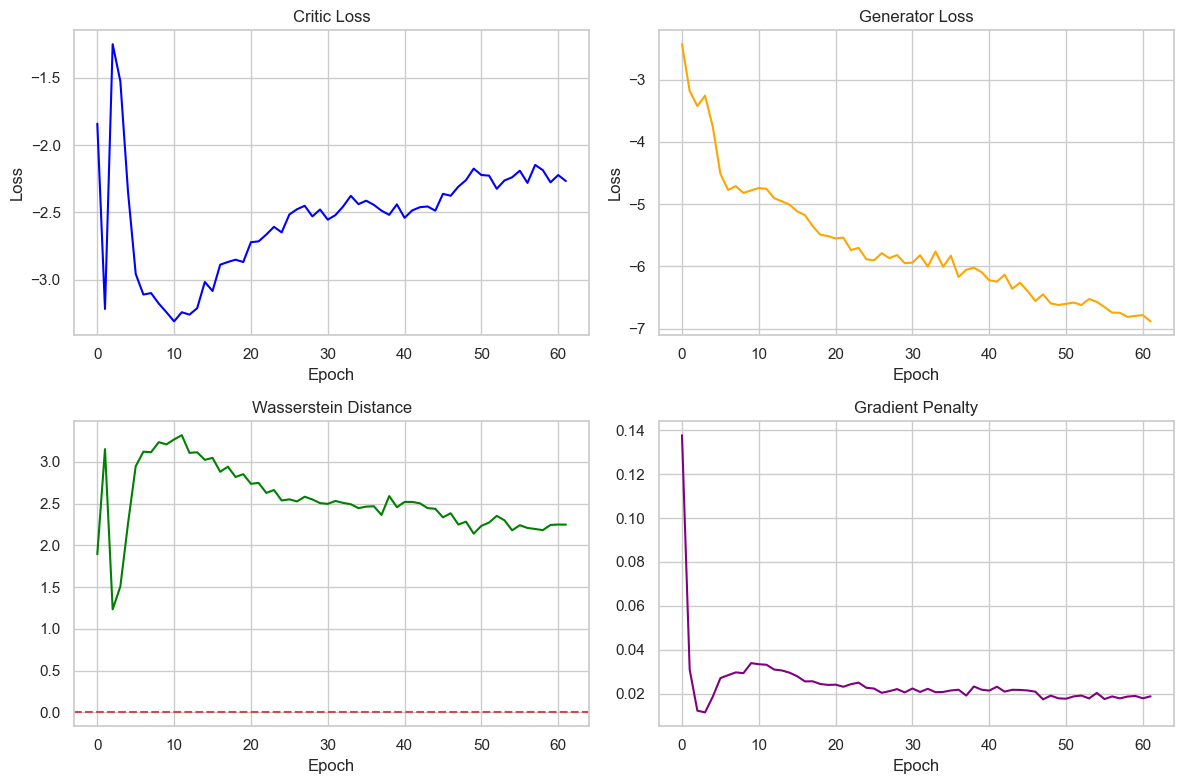

In [13]:

# %% [markdown]
# ## 6. Visualize Training Progress

# %%
def plot_losses(gan):
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    
    axes[0,0].plot(gan.c_losses, label='Critic Loss', color='blue')
    axes[0,0].set_title('Critic Loss')
    axes[0,0].set_xlabel('Epoch')
    axes[0,0].set_ylabel('Loss')
    
    axes[0,1].plot(gan.g_losses, label='Generator Loss', color='orange')
    axes[0,1].set_title('Generator Loss')
    axes[0,1].set_xlabel('Epoch')
    axes[0,1].set_ylabel('Loss')
    
    axes[1,0].plot(gan.w_distances, label='Wasserstein Distance', color='green')
    axes[1,0].set_title('Wasserstein Distance')
    axes[1,0].set_xlabel('Epoch')
    axes[1,0].axhline(y=0, color='r', linestyle='--')
    
    axes[1,1].plot(gan.gp_vals, label='Gradient Penalty', color='purple')
    axes[1,1].set_title('Gradient Penalty')
    axes[1,1].set_xlabel('Epoch')
    
    plt.tight_layout()
    os.makedirs('../figures', exist_ok=True)
    plt.savefig('../figures/cwgan_training_convergence.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_losses(gan)


In [14]:

# %% [markdown]
# ## 7. Generate Synthetic Samples and Evaluate Quality

# %%
# Generate a small batch for visualization
n_vis = 400
cond_vis = np.ones((n_vis, 1), dtype=np.float32)
num_synth_scaled, cat_synth = gan.generate(cond_vis, batch_size=64)

# Inverse scale numericals
if num_synth_scaled is not None:
    num_synth = scaler.inverse_transform(num_synth_scaled)
    print("Numerical value ranges after inverse transform:")
    for i, col in enumerate(feature_info['numerical']):
        print(f"  {col}: min={num_synth[:, i].min():.2f}, max={num_synth[:, i].max():.2f}")
else:
    num_synth = None

# Combine into DataFrame
df_synth_vis = combine_num_cat(num_synth, cat_synth, feature_info, column_order)


Numerical value ranges after inverse transform:
  Duration: min=4.12, max=70.69
  CreditAmount: min=252.93, max=17945.25
  Age: min=19.00, max=74.93
  Credit_per_Duration: min=24.54, max=1057.06



NUMERICAL FEATURE RANGE COMPARISON

FULL DATASET (All Applicants)
Duration             | min =       4.00 | max =      72.00
CreditAmount         | min =     250.00 | max =   18424.00
Age                  | min =      19.00 | max =      75.00
Credit_per_Duration  | min =      24.06 | max =    2482.67

REAL MINORITY CLASS (Defaulters)
Duration             | min =       6.00 | max =      72.00
CreditAmount         | min =     433.00 | max =   18424.00
Age                  | min =      19.00 | max =      74.00
Credit_per_Duration  | min =      24.06 | max =    2482.67

SYNTHETIC MINORITY (Generated)
Duration             | min =       4.12 | max =      70.69
CreditAmount         | min =     252.93 | max =   17945.25
Age                  | min =      19.00 | max =      74.93
Credit_per_Duration  | min =      24.54 | max =    1057.06

WASSERSTEIN DISTANCES (Numerical Features)
  Duration: 6.3724
  CreditAmount: 651.9397
  Age: 5.2258
  Credit_per_Duration: 30.6705

STATISTICAL SIMILARITY ME

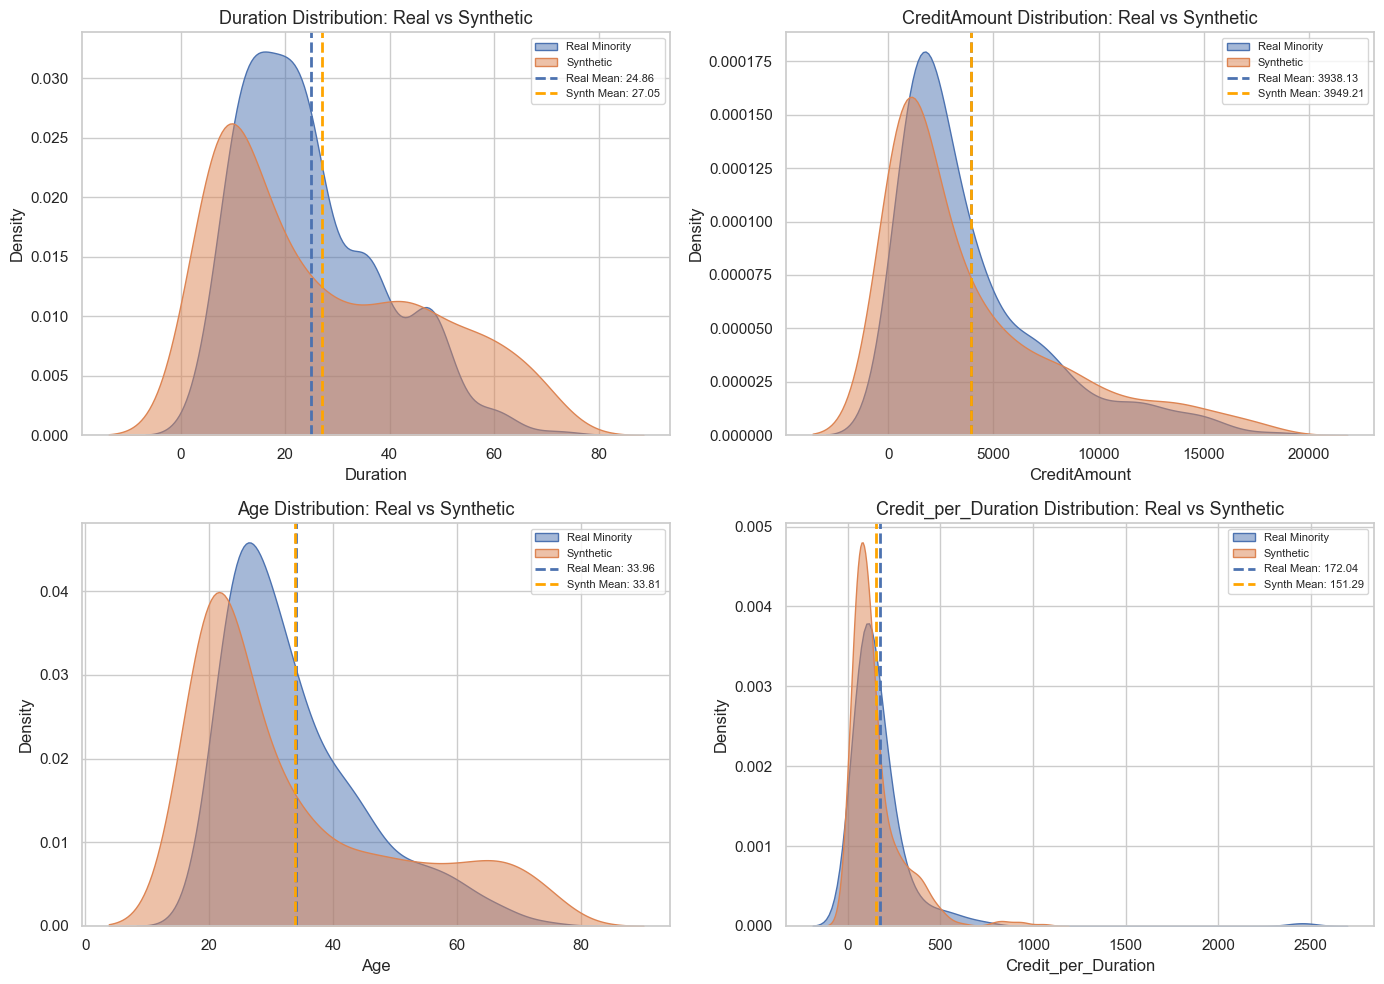

Plotting categorical proportions with value labels...


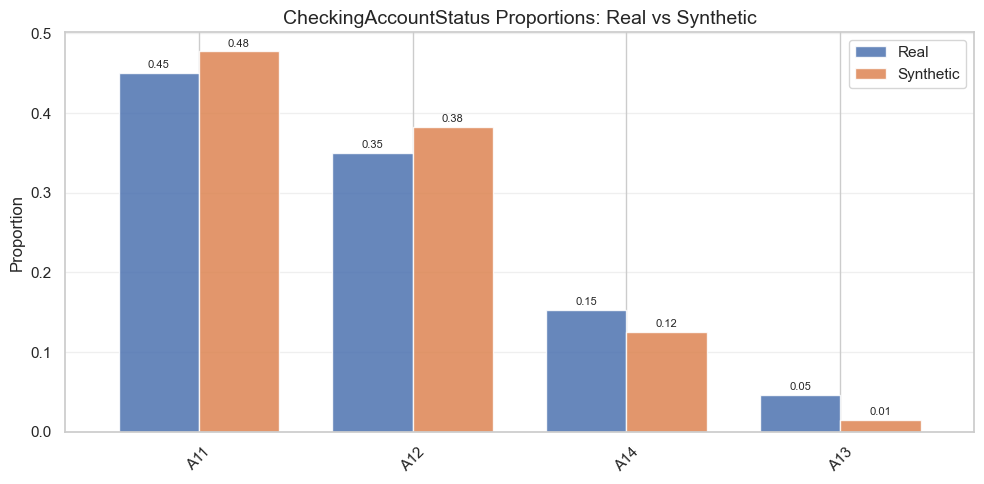

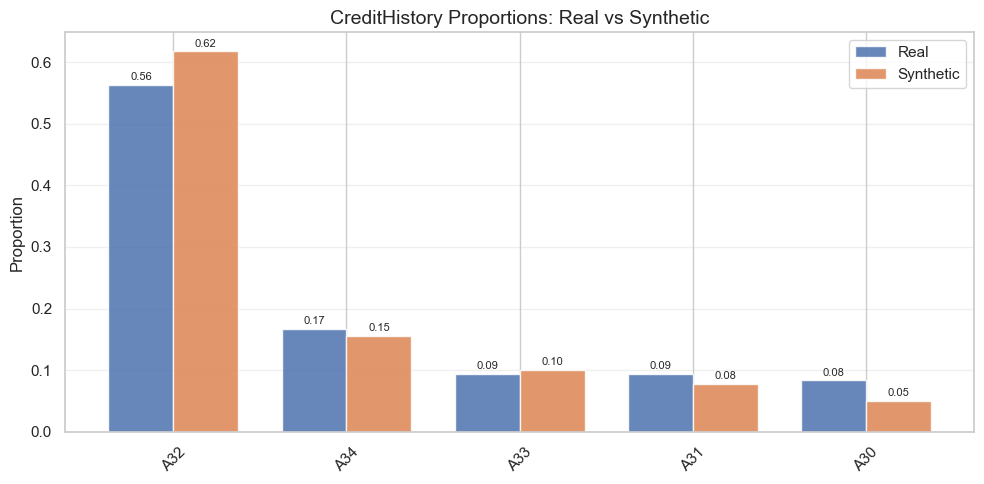

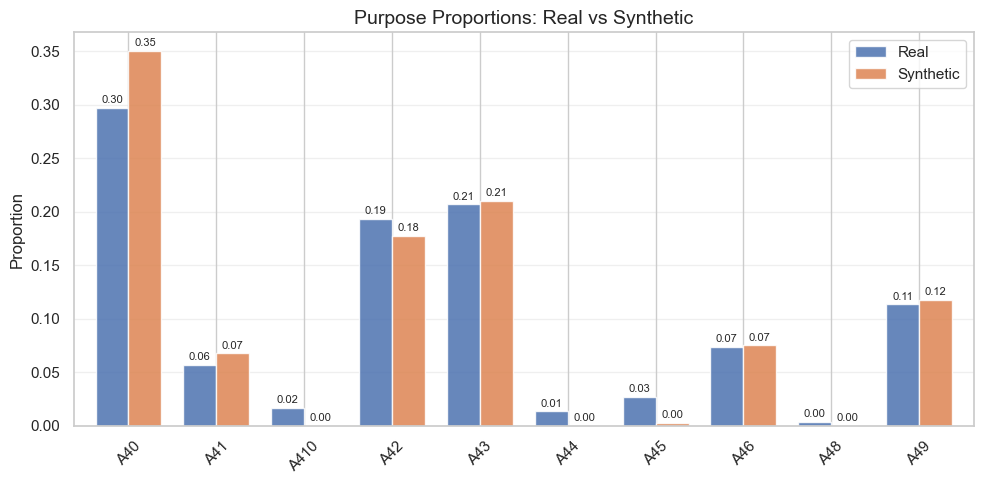

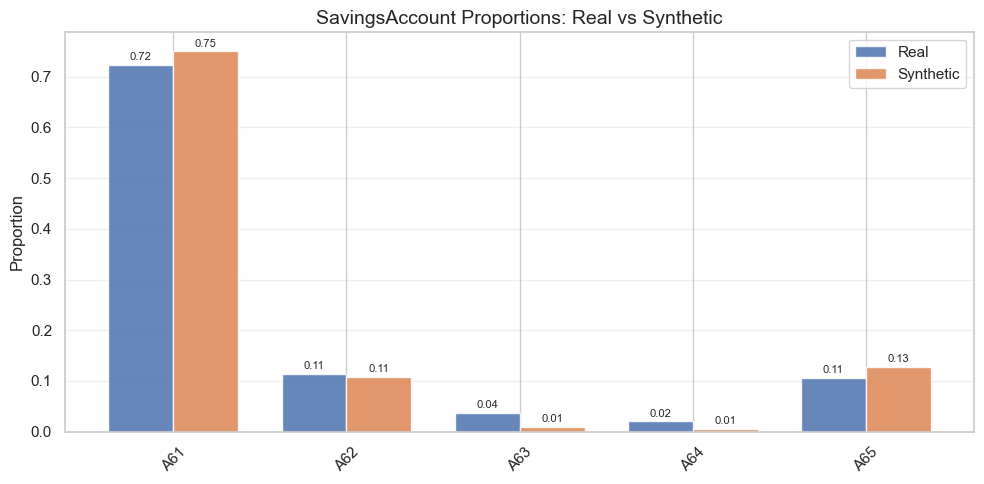

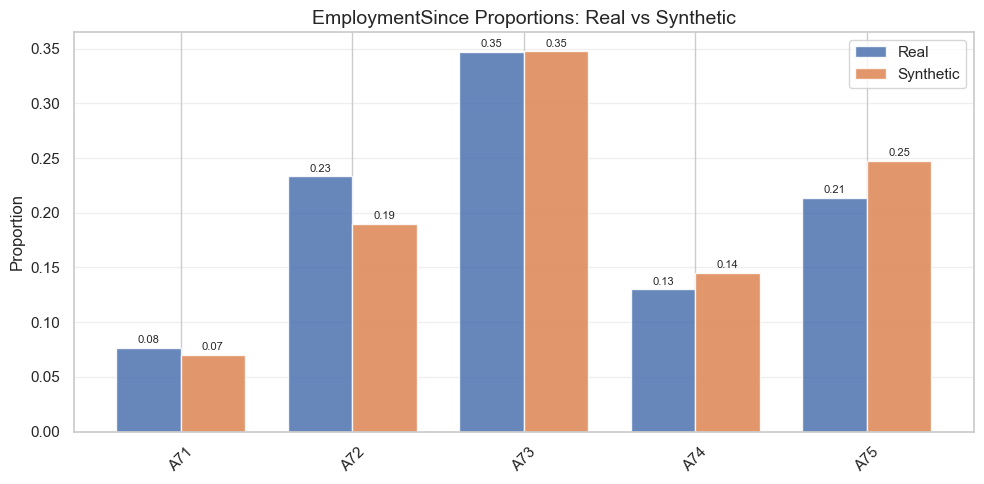

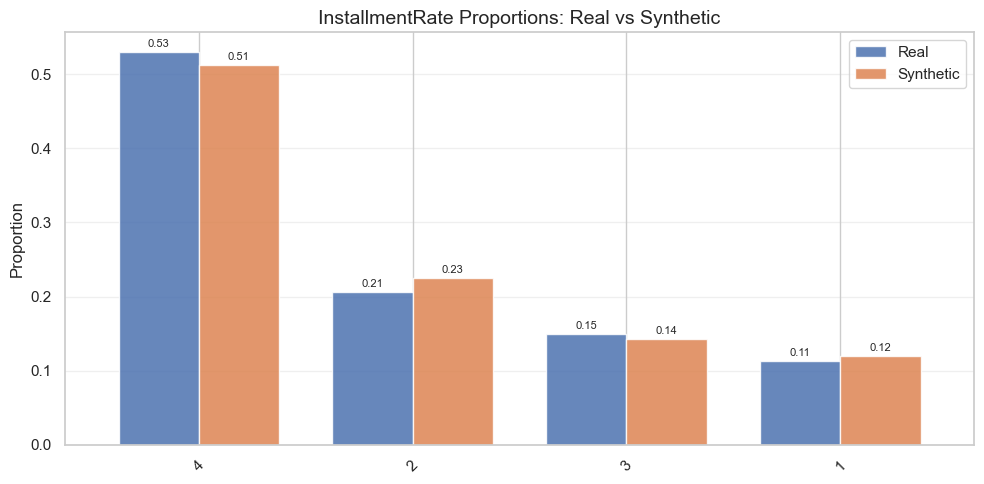

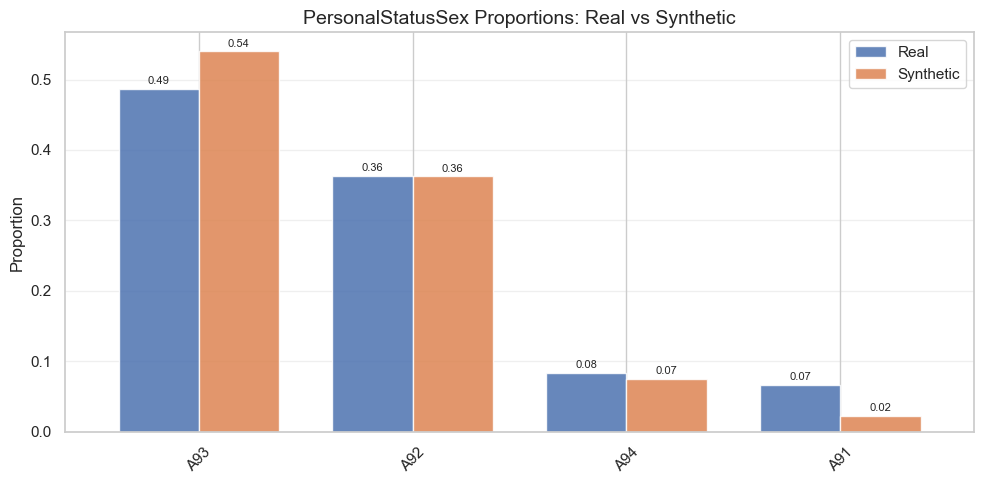

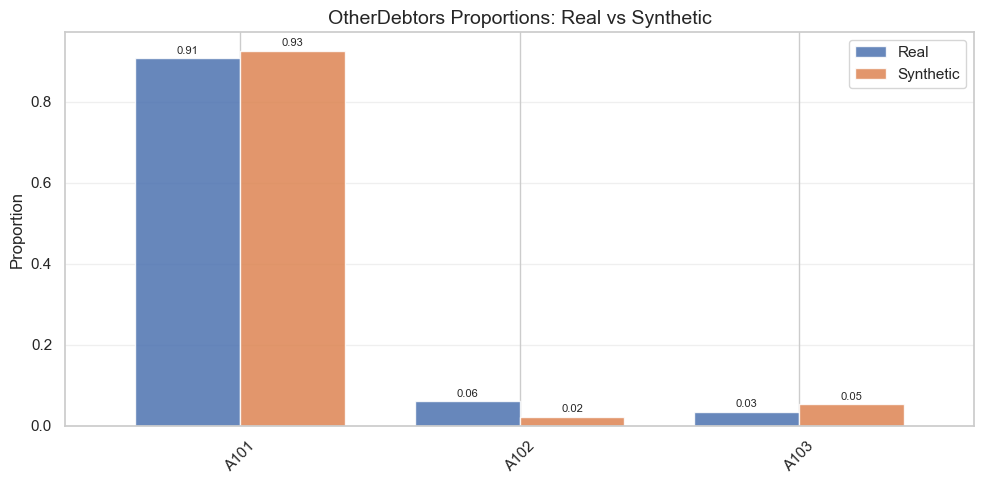

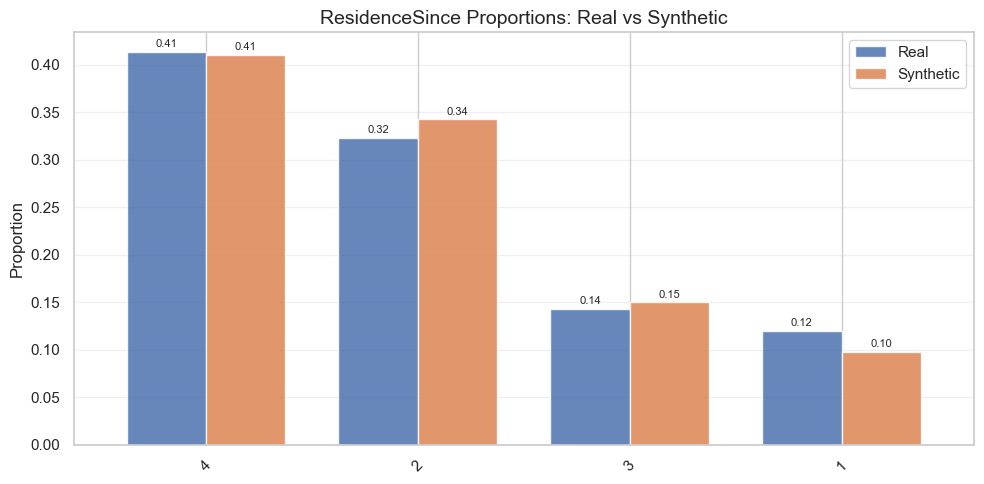

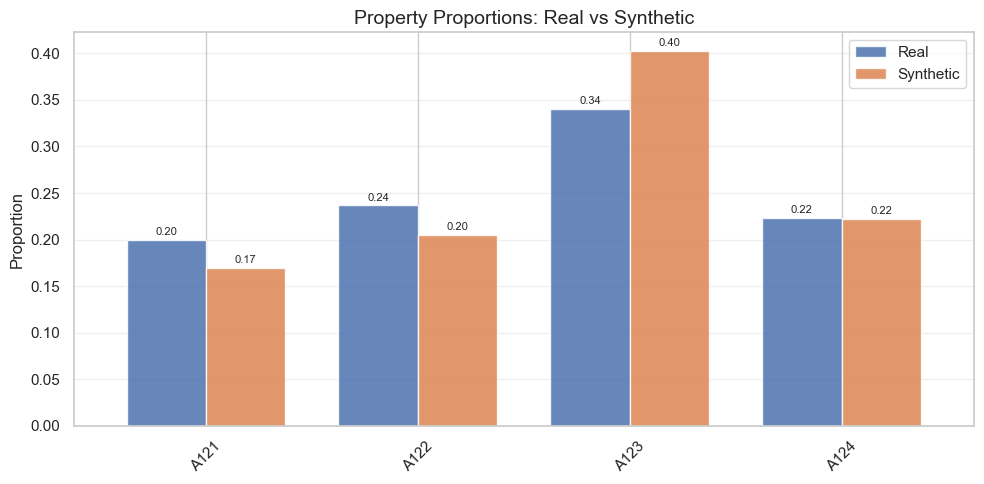

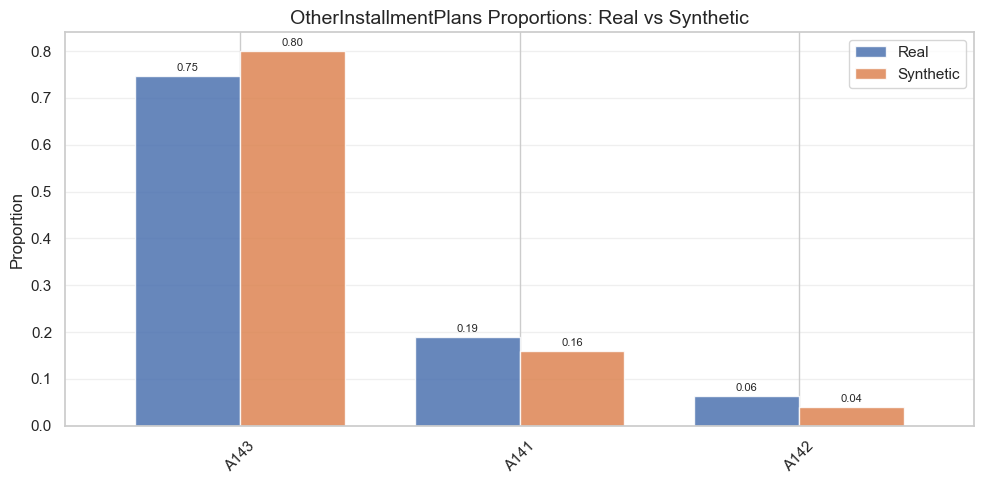

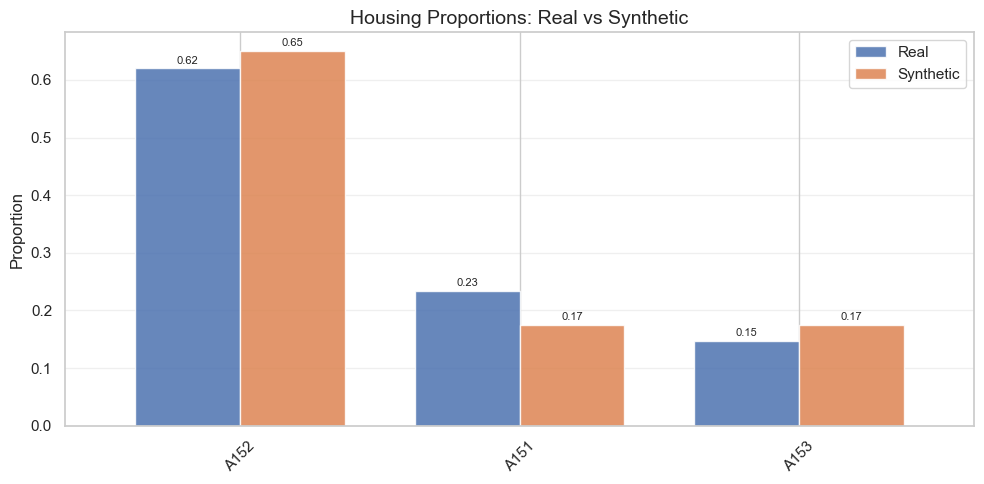

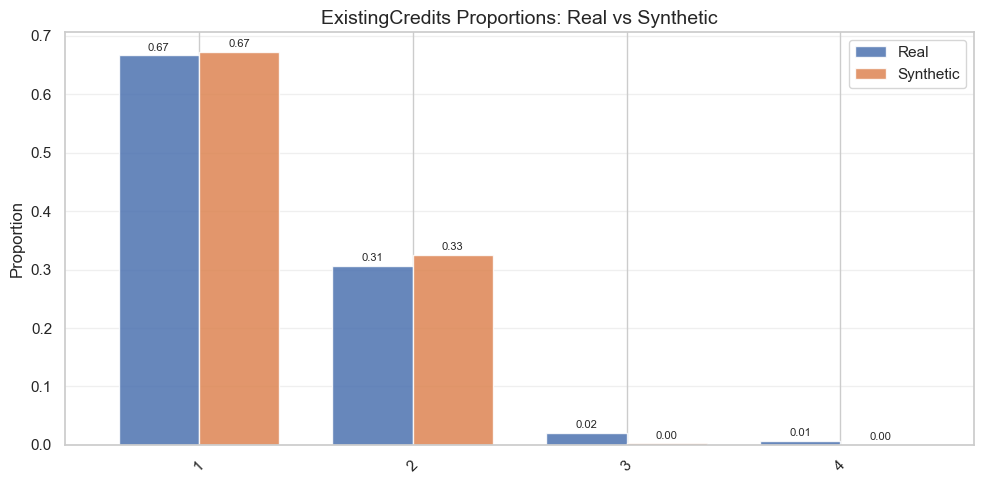

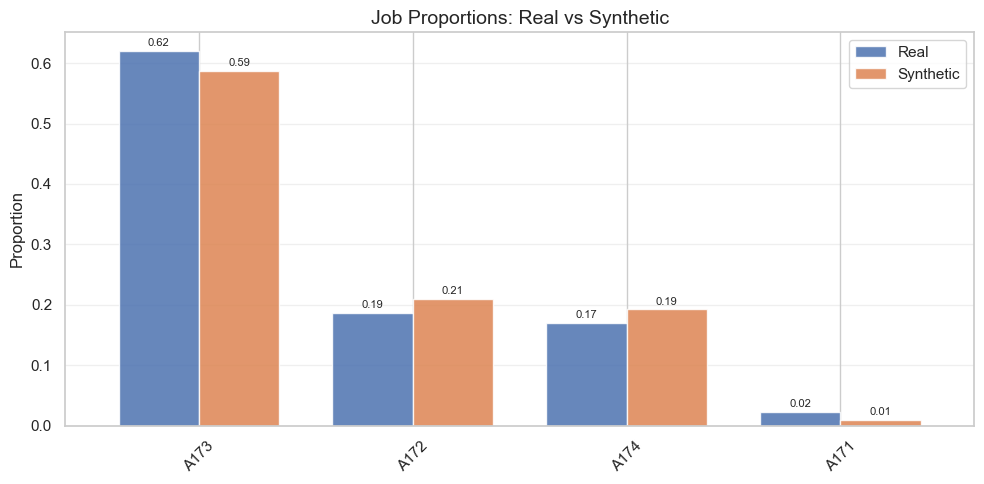

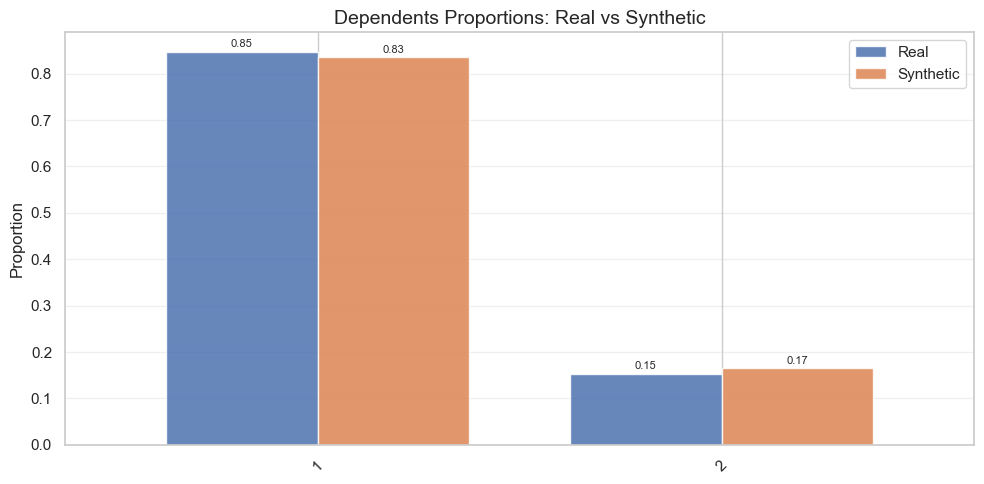

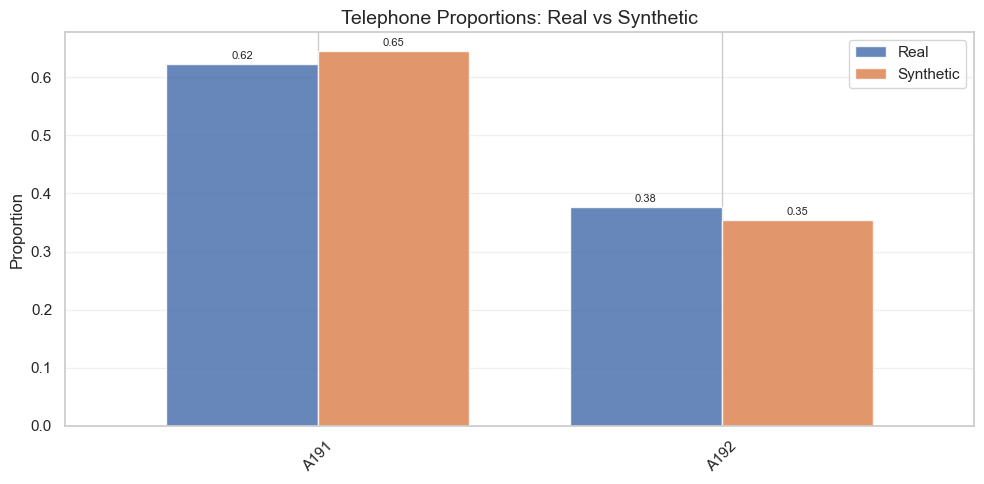

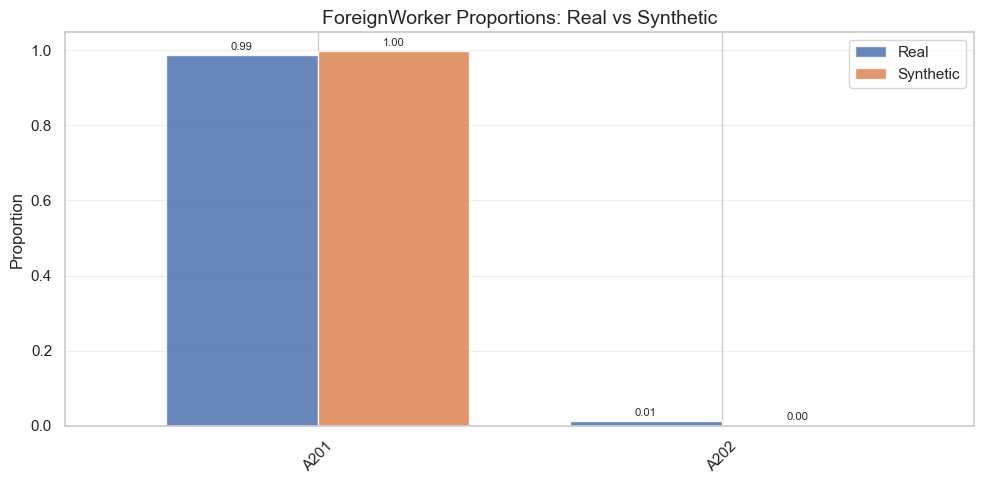

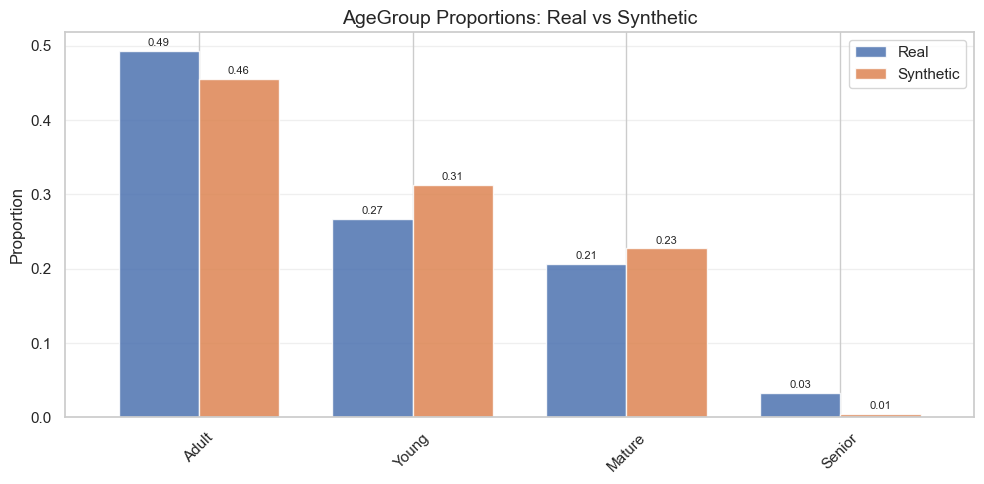

Plotting correlation matrices...


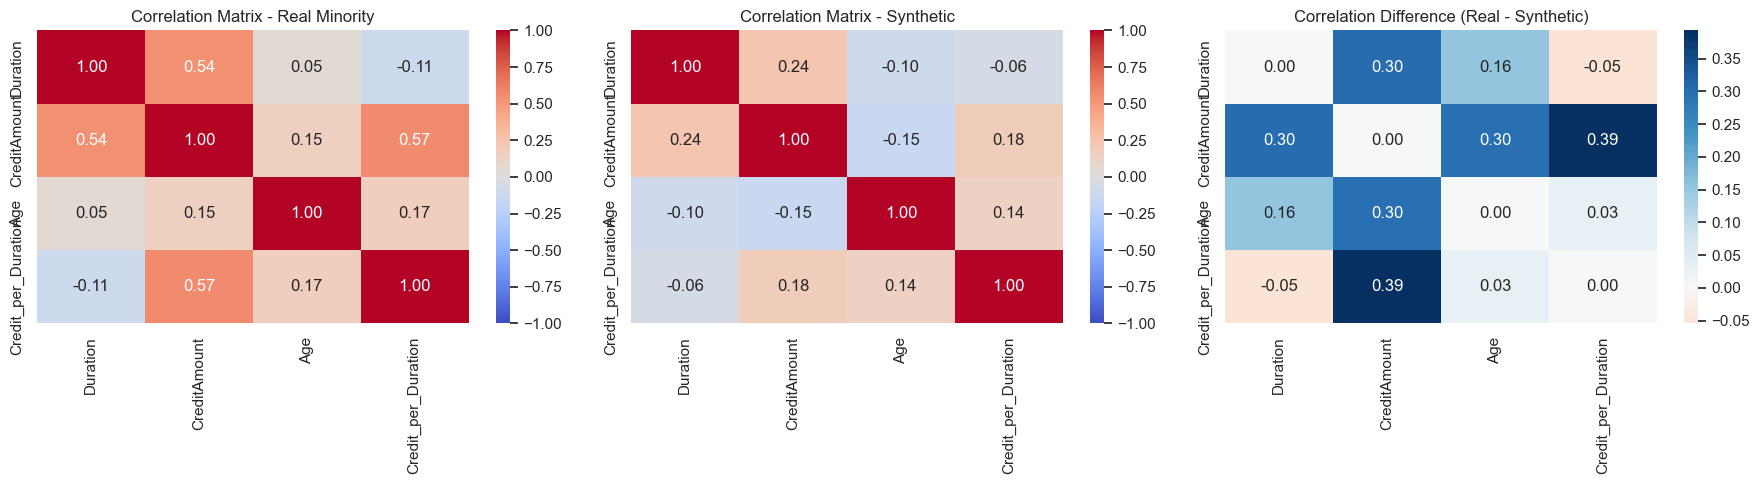

Generating PCA/t‑SNE projections...


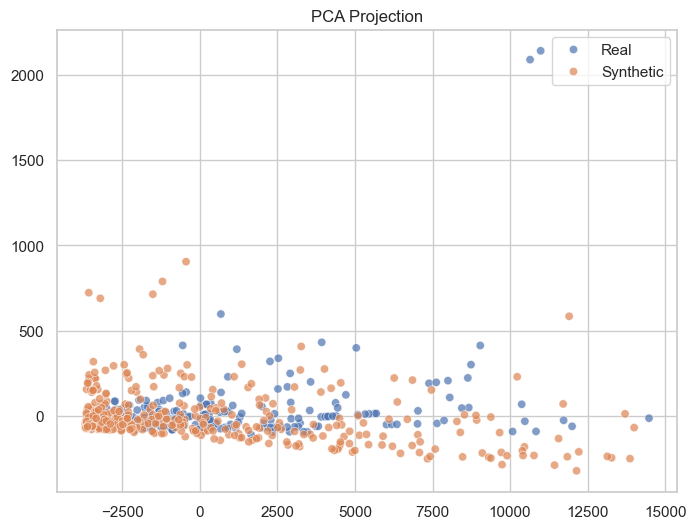

c:\Users\tsebaot.girma\Desktop\xai-credit-scoring-cwgan\scripts\evaluation.py:236: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  plt.savefig(f'{save_path}/cwgan_tsne.png', dpi=150, bbox_inches='tight')
c:\Users\tsebaot.girma\Desktop\xai-credit-scoring-cwgan\credit_env\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


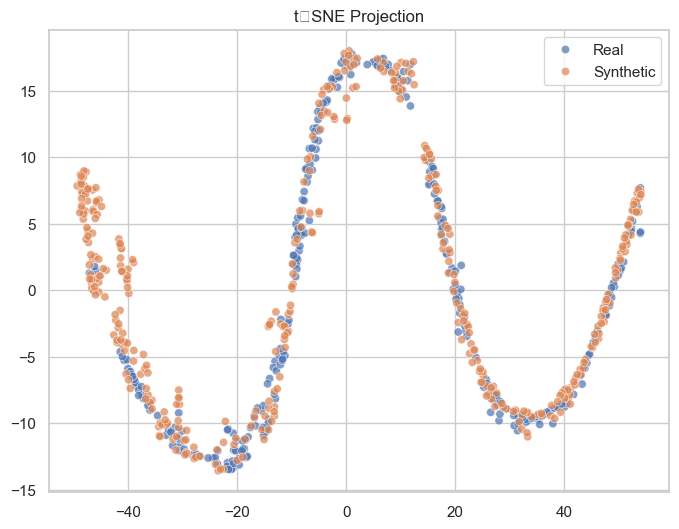


SYNTHETIC DATA QUALITY REPORT

1. NUMERICAL FEATURE STATISTICS:
----------------------------------------
             Feature  Real Mean Synth Mean  Mean Diff %   Real Std  Synth Std Std Diff %
----------------------------------------------------------------------------------------------------
            Duration      24.86      27.05          8.8%      13.28      19.70       48.3%
        CreditAmount    3938.13    3949.21          0.3%    3535.82    4249.54       20.2%
                 Age      33.96      33.81          0.5%      11.22      16.82       49.9%
 Credit_per_Duration     172.04     151.29         12.1%     223.84     148.07       33.9%

2. CATEGORICAL FEATURE FIDELITY:
----------------------------------------
  CheckingAccountStatus: Top category match ✓ | Real: A11 (45.0%) | Synth: A11 (47.8%)
  CreditHistory       : Top category match ✓ | Real: A32 (56.3%) | Synth: A32 (61.8%)
  Purpose             : Top category match ✓ | Real: A40 (29.7%) | Synth: A40 (35.0%)
  Savi

In [15]:
# In cwgan_training.ipynb, after Section 7
results = evaluate_generative_quality(
    df_synth_vis=df_synth_vis,
    feature_info=feature_info,
    df_processed=df_processed,
    target_col=target_col,
    minority_label=minority_label,
    save_path='../figures'
)

In [16]:

# %% [markdown]
# ## 8. Balance the Full Dataset (Optional - for Later Modeling)

# %%
# Compute feature ranges from full dataset for clipping
feature_ranges = {col: (df_processed[col].min(), df_processed[col].max()) 
                  for col in feature_info['numerical']}

# Generate enough synthetic samples to balance the entire dataset
majority_count = (df_processed[target_col] != minority_label).sum()
minority_count = (df_processed[target_col] == minority_label).sum()
needed = majority_count - minority_count
print(f"Full dataset: Majority={majority_count}, Minority={minority_count}, Need {needed} synthetic samples.")

if needed > 0:
    df_synth_full = generate_synthetic_samples(
        gan, scaler, needed, feature_info, column_order,
        minority_label=minority_label, target_col=target_col, 
        feature_ranges=feature_ranges
    )
    df_balanced = pd.concat([df_processed, df_synth_full], ignore_index=True)
    print("Balanced shape:", df_balanced.shape)
    print("Class counts after balancing:")
    print(df_balanced[target_col].value_counts())
    
    # Save balanced dataset
    df_balanced.to_csv("../data/processed/german_balanced_cwgan_improved.csv", index=False)
    print("Balanced dataset saved to ../data/processed/german_balanced_cwgan_improved.csv")
else:
    print("Dataset already balanced.")

# %% [markdown]
# ## 9. Next Steps
# - Train XGBoost on the balanced dataset
# - Compare with SMOTE and original imbalanced data using proper train/test split
# - Apply SHAP for explainability

Full dataset: Majority=700, Minority=300, Need 400 synthetic samples.
Balanced shape: (1400, 77)
Class counts after balancing:
Class
0    700
1    700
Name: count, dtype: int64
Balanced dataset saved to ../data/processed/german_balanced_cwgan_improved.csv
